<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Actividad 2 - Calidad, drift y anomalías
### Análisis de datos II - 4B2026

### Alumno: Fontanari Federico


In [1]:
!pip install great_expectations evidently kagglehub matplotlib-venn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.8 MB/s eta 0:00:00


In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

import great_expectations as gx
from great_expectations.data_context.types.base import ProgressBarsConfig

from evidently import Report, Dataset, DataDefinition
from evidently.metrics import ValueDrift

import kagglehub
import os

RANDOM_STATE = 14
pd.set_option("display.max_columns", None)

## 1. Carga de datos y separación en períodos

In [3]:
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")
df = pd.read_csv(os.path.join(path, "ds_salaries.csv"))
print(df.shape)
df.head()

Using Colab cache for faster access to the 'data-science-salaries-2023' dataset.
(3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
#Dividimos en 2 datasets
print("Distribución de filas por año:")
print(df["work_year"].value_counts().sort_index())

referencia = df[df["work_year"].isin([2020, 2021])].copy()
actual = df[df["work_year"].isin([2022, 2023])].copy()

print(f"\nReferencia (2020-2021): {len(referencia)} filas")
print(f"Actual (2022-2023): {len(actual)} filas")

Distribución de filas por año:
work_year
2020      76
2021     230
2022    1664
2023    1785
Name: count, dtype: int64

Referencia (2020-2021): 306 filas
Actual (2022-2023): 3449 filas


La separación no queda pareja. El período de referencia tiene apenas 306 filas (76 de 2020 + 230 de 2021) contra 3.449 del período actual. Tiene sentido ya que el dataset se fue nutriendo con más respuestas a medida que pasaron los años. Una referencia tan chica hace que el PSI (que vamos a calcular más adelante) sea más ruidoso de lo ideal, sobre todo para la variable continua, donde los bordes de los bins se definen solo con esos 306 puntos.

## 2. Selección de variables relevantes

Elegimos las variables sugeridas en la consigna: `salary_in_usd`, `experience_level`, `remote_ratio` y `company_size`. No es una elección arbitraria: en la Actividad 1, una vez sacado el leakage (`salary` y  `salary_currency`), el PFI del Modelo 2 ranqueó a `experience_level` como la 2da variable más importante y a `company_size` con importancia baja pero no nula. `remote_ratio` quedó en un rango intermedio. Si estas variables cambian de distribución, es razonable esperar que afecte al modelo que entrenamos. `salary_in_usd` la incluimos porque es la variable que el modelo predice y ver cómo se mueve su distribución en el tiempo es importante.

## 3. Chequeos de calidad

Aplicamos 3 chequeos con `great_expectations`, sobre las 4 variables elegidas: **Completitud** (nulos), **Validez** (rangos y categorías esperadas) y **Unicidad** (filas duplicadas). Para validez mostramos dos enfoques distintos, porque responden preguntas diferentes y las dos son útiles.

In [5]:
context = gx.get_context()
context.variables.progress_bars = ProgressBarsConfig(globally=False, metric_calculations=False)
context.variables.save()

data_source = context.data_sources.add_pandas("pandas_source") # Le aviso que voy a trabajar con formato de pandas
data_asset = data_source.add_dataframe_asset(name="salaries_asset")  # Defino un asset - un dataset
batch_definition = data_asset.add_batch_definition_whole_dataframe("batch_def")  # Cada vez que se pida un batch de este dataset, que se tome todo el dataset
batch = batch_definition.get_batch(batch_parameters={"dataframe": df}) # Crear el batch



INFO:great_expectations.data_context.types.base:Created temporary directory '/tmp/tmpg8fc4hiy' for ephemeral docs site


### Completitud

In [6]:
# 1. Completitud: nulos en las 4 variables elegidas
variables_elegidas = ["salary_in_usd", "experience_level", "remote_ratio", "company_size"]

print("Completitud (nulos):")
for var in variables_elegidas:
    resultado = batch.validate(gx.expectations.ExpectColumnValuesToNotBeNull(column=var))
    print(f"  {var:20s} -> {'OK' if resultado.success else 'FAIL'}")

Completitud (nulos):
  salary_in_usd        -> OK
  experience_level     -> OK
  remote_ratio         -> OK
  company_size         -> OK


No se observan valores nulos en ninguna de las 4 variables elegidas

### Validez - Enfoque 1: valores esperados por conocimiento del dominio

Este es el enfoque que usa en la notebook de clase `clase_03_calidad.ipynb`. Los valores esperados se escriben directamente a partir de lo que sabemos del dominio. Por ejemplo, sabemos que `experience_level` solo puede ser EN/MI/SE/EX, sin importar en qué período estemos. Se valida contra **todo el dataset**. Es un chequeo de esquema general. Responde la pregunta de si los datos respetan las reglas de un registro válido para este problema, las hayamos visto antes o no.

In [7]:
# 2. Validez: rangos y categorías esperadas

res_exp = batch.validate(gx.expectations.ExpectColumnValuesToBeInSet(
    column="experience_level", value_set=["EN", "MI", "SE", "EX"]
))
res_remote = batch.validate(gx.expectations.ExpectColumnValuesToBeInSet(
    column="remote_ratio", value_set=[0, 50, 100]
))
res_size = batch.validate(gx.expectations.ExpectColumnValuesToBeInSet(
    column="company_size", value_set=["S", "M", "L"]
))
res_salary = batch.validate(gx.expectations.ExpectColumnValuesToBeBetween(
    column="salary_in_usd", min_value=1
))

print("Validez:")
print(f"  experience_level en {{EN,MI,SE,EX}} -> {'OK' if res_exp.success else 'FAIL'}")
print(f"  remote_ratio en {{0,50,100}}        -> {'OK' if res_remote.success else 'FAIL'}")
print(f"  company_size en {{S,M,L}}           -> {'OK' if res_size.success else 'FAIL'}")
print(f"  salary_in_usd > 0                  -> {'OK' if res_salary.success else 'FAIL'}")

Validez:
  experience_level en {EN,MI,SE,EX} -> OK
  remote_ratio en {0,50,100}        -> OK
  company_size en {S,M,L}           -> OK
  salary_in_usd > 0                  -> OK


Las 4 variables pasan satisfactoriamente. Cumplen las reglas fijas del dominio que no dependen del período que estemos mirando. Este chequeo sirve para agarrar errores de carga o valores imposibles (una categoría mal tipeada, un salario negativo), no para detectar cambios en el tiempo.

### Validez - Enfoque 2: estabilidad del esquema entre períodos

En este enfoque nos preguntamos si el período **actual** usa exactamente las mismas categorías que vimos en el período de **referencia**, o apareció/desapareció alguna categoria. El `value_set` ya no lo escribimos nosotros. Lo calculamos a partir de los valores observados en `referencia`, y validamos solo el batch de `actual` contra eso.

Esto es distinto del PSI de la Sección 4. Esta metrica mide si las proporciones de las categorías cambiaran. Este chequeo mide si el conjunto de categorías en sí cambió. Es decir, si apareció una categoría nueva que nunca vimos antes, o alguna desapareció por completo. Son preguntas complementarias ya que se puede tener drift de proporciones sin un drift de esquema, o viceversa.

No incluimos `salary_in_usd` en este enfoque porque es continua. Comparar los valores exactos entre períodos no tiene sentido.

In [8]:
batch_actual = batch_definition.get_batch(batch_parameters={"dataframe": actual})

print("Validez (Enfoque 2 - esquema de actual vs. categorías vistas en referencia):")
for var in ["experience_level", "remote_ratio", "company_size"]:
    valores_esperados = sorted(referencia[var].unique().tolist(), key=str)
    resultado = batch_actual.validate(
        gx.expectations.ExpectColumnValuesToBeInSet(column=var, value_set=valores_esperados)
    )
    print(f"  {var:20s} esperado={valores_esperados} -> {'OK' if resultado.success else 'FAIL'}")
    if not resultado.success:
        print(f"    valores nuevos encontrados: {resultado.result['partial_unexpected_list']}")

Validez (Enfoque 2 - esquema de actual vs. categorías vistas en referencia):
  experience_level     esperado=['EN', 'EX', 'MI', 'SE'] -> OK
  remote_ratio         esperado=[0, 100, 50] -> OK
  company_size         esperado=['L', 'M', 'S'] -> OK


Las 3 variables categóricas dan OK. Ninguna categoría nueva apareció en `actual` que no estuviera ya en `referencia` ni ninguna desapareció. **No hay drift de esquema** en estas variables.

Este enfoque nos sirve para saber si por ejemplo hay que actualizar el `OneHotEncoder` con el que se entrenó el modelo.

### Unicidad

In [9]:
# 3. Unicidad: filas completamente duplicadas
res_unicidad = batch.validate(gx.expectations.ExpectCompoundColumnsToBeUnique(
    column_list=list(df.columns)
))

n_en_grupos = res_unicidad.result["unexpected_count"]      # keep=False
n_sobrantes = df.duplicated(keep="first").sum()           # copias extra
n_unicas = len(df.drop_duplicates())

print(f"Unicidad: {'OK' if res_unicidad.success else 'FAIL'}")
print(f"Filas que forman parte de un grupo duplicado: {n_en_grupos} de {len(df)} ({n_en_grupos/len(df)*100:.1f}%)")
print(f"Copias sobrantes que se eliminan al deduplicar: {n_sobrantes}")
print(f"Filas únicas después de deduplicar: {n_unicas}")
print(f"Control: {n_unicas} + {n_sobrantes} = {n_unicas + n_sobrantes}")

Unicidad: FAIL
Filas que forman parte de un grupo duplicado: 1715 de 3755 (45.7%)
Copias sobrantes que se eliminan al deduplicar: 1171
Filas únicas después de deduplicar: 2584
Control: 2584 + 1171 = 3755


La Unicidad da una alerta fuerte: **1.715 filas (45.7%) forman parte de algún grupo de duplicados exactos**. Al deduplicar se eliminan 1.171 copias sobrantes (31.2% del dataset) y quedan 2.584 filas realmente distintas.

No necesariamente esto es un error de carga. El dataset tiene columnas bastante "gruesas" (`job_title`, `experience_level`, `salary` redondeado, `company_size` con 3 valores posibles) así que dos publicaciones de trabajo genuinamente distintas  pueden coincidir en todas las columnas. Por ejemplo, dos "Data Scientist Senior", que cobran USD 150.000, full remoto, en una empresa mediana de EE.UU. Aun así, no podemos descartar que también haya duplicados de carga real. La misma fila podria estar cargada dos veces.

## 4. Cálculo de PSI

Calculamos el Population Stability Index comparando referencia (2020-2021) vs. actual (2022-2023) para las 4 variables. Usamos `evidently` con el mismo esquema que la notebook de clase (`clase_03_deteccion_drift.ipynb`). Primero armamos dos `Dataset` (actual y referencia) y corremos un `Report` con una métrica `ValueDrift(method="psi")` por variable.

El umbral que establecemos es el estándar de la industria y el mismo que se usa en clase:
- PSI < 0.10 -> sin drift significativo
- 0.10 ≤ PSI > 0.25 -> drift moderado
- PSI ≥ 0.25 -> drift significativo

In [10]:
variables_drift = ["salary_in_usd", "experience_level", "remote_ratio", "company_size"]

# Instancio un Dataset de Evidently por período
ref_dataset = Dataset.from_pandas(referencia[variables_drift], data_definition=DataDefinition())
act_dataset = Dataset.from_pandas(actual[variables_drift], data_definition=DataDefinition())

# Reporte con PSI para cada variable
report_psi = Report(metrics=[
    ValueDrift(column=var, method="psi", threshold=0.25) for var in variables_drift
])

# El orden: primero actual, después referencia
resultado_psi = report_psi.run(act_dataset, ref_dataset)

resumen_psi = pd.DataFrame([
    {"variable": m["config"]["column"], "psi": m["value"]}
    for m in resultado_psi.dict()["metrics"]
])
resumen_psi["drift"] = pd.cut(
    resumen_psi["psi"], bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=["sin drift", "moderado", "significativo"], right=False
)
resumen_psi.sort_values("psi", ascending=False)

,variable,psi,drift
3,company_size,2.198147,significativo
2,remote_ratio,1.191421,significativo
0,salary_in_usd,0.920436,significativo
1,experience_level,0.741723,significativo


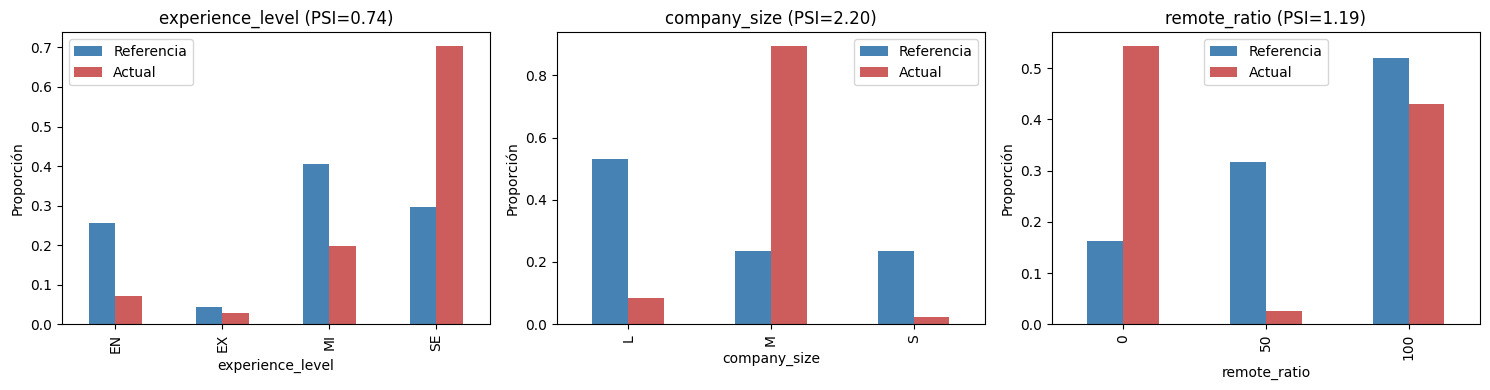

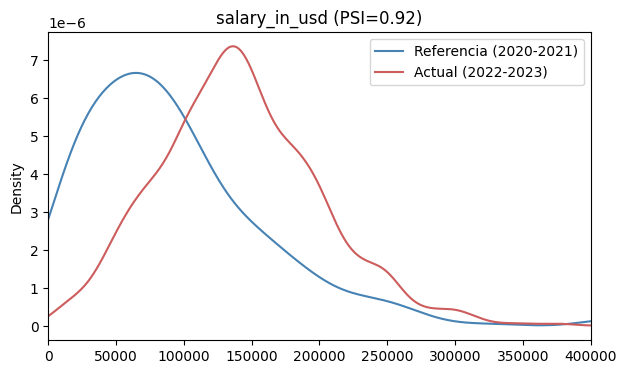

salary_in_usd - mediana referencia: 79833.0
salary_in_usd - mediana actual:     138750.0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
psi_por_variable = resumen_psi.set_index("variable")["psi"]

for ax, var in zip(axes, ["experience_level", "company_size", "remote_ratio"]):
    proporciones = pd.DataFrame({
        "Referencia": referencia[var].value_counts(normalize=True),
        "Actual": actual[var].value_counts(normalize=True),
    }).fillna(0).sort_index()
    proporciones.plot(kind="bar", ax=ax, color=["steelblue", "indianred"])
    ax.set_title(f"{var} (PSI={psi_por_variable[var]:.2f})")
    ax.set_ylabel("Proporción")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
referencia["salary_in_usd"].plot(kind="kde", label="Referencia (2020-2021)", ax=ax, color="steelblue")
actual["salary_in_usd"].plot(kind="kde", label="Actual (2022-2023)", ax=ax, color="indianred")
ax.set_title(f"salary_in_usd (PSI={psi_por_variable['salary_in_usd']:.2f})")
ax.set_xlim(0, 400000)
ax.legend()
plt.show()

print("salary_in_usd - mediana referencia:", referencia["salary_in_usd"].median())
print("salary_in_usd - mediana actual:    ", actual["salary_in_usd"].median())

Las 4 variables dan **muy por encima** del umbral de drift significativo (0.25):

| Variable | PSI | Cambios |
|---|---|---|
| `experience_level` | **0.74** | Senior (SE) aumenta su participacion mientras que Junior (EN) e Intermediate (MI)  baja. |
| `company_size` | **2.20** | Empresas medianas (M) aumentan considerablemente su proporcion. Grandes (L) y pequeñas (S) la disminuyen |
| `remote_ratio` | **1.19** | Presencial (0%) aumenta su proporcion mientras que híbrido (50%) casi desaparece. Full remoto baja un poco. |
| `salary_in_usd` | **0.92** | Toda la distribución se corre hacia la derecha, es decir que los sueldos en dolares aumentan |

**¿A qué tipo de drift podría corresponder cada una?**

**`experience_level`, `company_size` y `remote_ratio`.** Son features de entrada del modelo de la Actividad 1, así que un cambio en su distribución corresponde a un **covariate shift**. Cambia P(X), es decir, la población que llega es distinta a la de entrenamiento. Posibles causas: en `experience_level`, que en los últimos años la encuesta haya captado más perfiles con experiencia; en `remote_ratio`, la vuelta a la presencialidad después de la pandemia (2020-2021 fue un período atípico de trabajo remoto); en `company_size`, un cambio en el tipo de empresas que responden la encuesta.

**`salary_in_usd`.** Como es el target del modelo, a primera vista podría tratarse de un **label shift**. Sin embargo, nuestra conjetura es que buena parte del corrimiento sea una consecuencia del covariate shift que vemos en las otras variables. Si en 2022-2023 hay muchos más perfiles Senior, es esperable que el salario suba aunque la relación entre las características del puesto y el salario no haya cambiado. Algo similar podría estar pasando con variables que no incluimos en este análisis, como el país de residencia: si cambió la proporción de puestos en países con salarios más altos, eso también empujaría el salario hacia arriba. Por último, podrían influir factores de mercado, como aumentos salariales generales en el sector. Confirmar cuál de estas explicaciones pesa más requeriría un análisis específico, que queda fuera del alcance de esta actividad.


## 5. Estrategia frente al drift

El PFI del Modelo 2 de la Actividad 1 (el que no tiene leakage) rankeaba a `employee_residence`, `experience_level` y `job_title` como las variables más importantes. De las 4 variables que auditamos, `experience_level` es justo una de las más importantes del modelo, y es la que muestra un covariate shift severo (PSI=0.74). `company_size` y `remote_ratio` pesan bastante menos en el PFI. Su drift, aunque enorme en términos de PSI, probablemente impacte menos en las predicciones.

De las estrategias vistas en clase (reentrenamiento, feature engineering, ensamble), vamos a elegir **reentrenamiento periódico con datos recientes** como estrategia principal:

- El drift que encontramos parece ser, sobre todo, un cambio real en la composición de la población (más Senior, más empresas medianas, más presencialidad) y no un problema puntual de la fuente de datos. Un Random Forest entrenado con las proporciones de 2020-2021  tiene sus hojas ajustadas a una mezcla de población que ya no representa a quienes va a predecir. Reentrenar con datos actuales corrige esto directamente, sin necesidad de intentar "adivinar" cómo compensar el corrimiento.
- **Feature engineering** lo sumaríamos como complemento, pero no como solución principal. El drift que encontramos es un cambio en la proporción de categorías que ya existían, y eso no se corrige transformando las variables. Aun así, podría ayudar a que el modelo sea más robusto a futuros cambios. Por ejemplo, `company_size` y `remote_ratio` son las variables con más drift pero tienen poca importancia en el modelo. Valdría la pena evaluar si conviene quitarlas ya que aportan poco a la predicción y son las más inestables entre períodos. Otra opción sería agrupar categorías con pocos registros (por ejemplo, países en regiones o agrupar paises con pocos casos), para que el modelo dependa menos de categorías que en un período tienen muy pocos casos.
- **Ensamble** por ejemplo podria ser combinar un modelo entrenado con 2020-2021 y otro con 2022-2023. Lo descartamos como estrategia principal ya que la referencia de 2020-2021 es chica (306 filas) y corresponde a un momento muy particular (pandemia, pico de trabajo remoto). No es un período "normal" que valga la pena preservar en el ensamble. Mejor apoyarse en los datos recientes, que además son mucho más abundantes.

## 6. Detección de anomalías

Usamos `salary_in_usd`, `remote_ratio`, `work_year` (numéricas) y codificamos `experience_level` y `company_size` como ordinales (EN<MI<SE<EX, S<M<L), para tener una combinación de variables donde tenga sentido buscar anomalías multivariadas.

**Antes de correr LOF, deduplicamos** el dataset. Con el 45.7% de filas duplicadas que encontramos en la Sección 3, LOF tira un warning de "duplicate values" . Varios puntos quedan a distancia 0 de sus "vecinos" (que en realidad son copias idénticas), y la densidad local se calcula mal. Isolation Forest no tiene este problema porque no depende de distancias entre vecinos.

In [12]:
df_dedup = df.drop_duplicates().reset_index(drop=True)
print(f"Filas originales: {len(df)} -> únicas: {len(df_dedup)}")

exp_map = {"EN": 0, "MI": 1, "SE": 2, "EX": 3}
size_map = {"S": 0, "M": 1, "L": 2}
df_dedup["experience_level_ord"] = df_dedup["experience_level"].map(exp_map)
df_dedup["company_size_ord"] = df_dedup["company_size"].map(size_map)

features_anomalias = ["salary_in_usd", "remote_ratio", "work_year", "experience_level_ord", "company_size_ord"]
X = df_dedup[features_anomalias]
X_scaled = StandardScaler().fit_transform(X)

Filas originales: 3755 -> únicas: 2584


In [13]:
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_STATE)
df_dedup["isof_pred"] = iso.fit_predict(X_scaled)
df_dedup["isof_score"] = iso.decision_function(X_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_dedup["lof_pred"] = lof.fit_predict(X_scaled)
df_dedup["lof_score"] = lof.negative_outlier_factor_

print(f"Anomalías según Isolation Forest: {(df_dedup.isof_pred == -1).sum()}")
print(f"Anomalías según LOF:              {(df_dedup.lof_pred == -1).sum()}")
print(f"Coinciden ambos métodos:          {((df_dedup.isof_pred == -1) & (df_dedup.lof_pred == -1)).sum()}")
print(f"Solo Isolation Forest:            {((df_dedup.isof_pred == -1) & (df_dedup.lof_pred == 1)).sum()}")
print(f"Solo LOF:                         {((df_dedup.isof_pred == 1) & (df_dedup.lof_pred == -1)).sum()}")

Anomalías según Isolation Forest: 130
Anomalías según LOF:              130
Coinciden ambos métodos:          12
Solo Isolation Forest:            118
Solo LOF:                         118


Con contamination=0.05 en ambos, cada método marca 130 registros como anómalos, pero **solo coinciden en 12**. La mayoría de las anomalías que encuentra cada método son distintas.

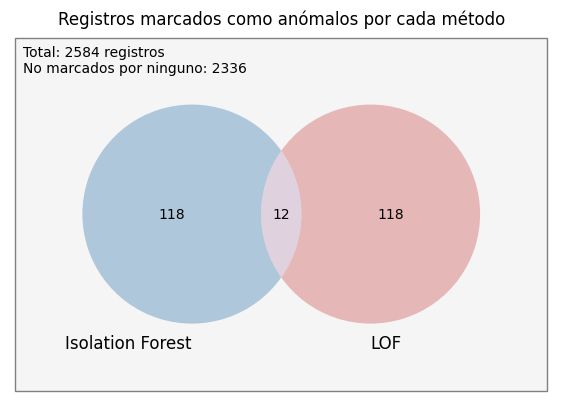

In [14]:
from matplotlib_venn import venn2
from matplotlib.patches import Rectangle

anomalias_isof = set(df_dedup.index[df_dedup["isof_pred"] == -1])
anomalias_lof = set(df_dedup.index[df_dedup["lof_pred"] == -1])
n_normales = len(df_dedup) - len(anomalias_isof | anomalias_lof)

fig, ax = plt.subplots(figsize=(7, 5))
venn2([anomalias_isof, anomalias_lof], set_labels=("Isolation Forest", "LOF"),
      set_colors=("steelblue", "indianred"), ax=ax)

# Rectángulo de fondo = universo de registros (no está a escala)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
m = 0.15
ax.add_patch(Rectangle((x0 - m, y0 - m), (x1 - x0) + 2 * m, (y1 - y0) + 2 * m,
                       facecolor="whitesmoke", edgecolor="gray", zorder=0))
ax.text(x0 - m + 0.03, y1 + m - 0.03,
        f"Total: {len(df_dedup)} registros\nNo marcados por ninguno: {n_normales}",
        ha="left", va="top", fontsize=10)
ax.set_xlim(x0 - m - 0.02, x1 + m + 0.02)
ax.set_ylim(y0 - m - 0.02, y1 + m + 0.02)
ax.set_title("Registros marcados como anómalos por cada método")
plt.show()

### Herramientas para analizar cada caso

Para analizar los registros anómalos usamos tres funciones, que aplicamos de la misma forma en los tres casos:

- `mirada_univariada`: para cada variable por separado, indica qué tan común es el valor del registro. Sirve para ver si hay algún valor raro por sí solo.
- `mirada_multivariada`: para las combinaciones de variables de a 2 y para las 4 juntas, cuenta cuántos registros comparten los mismos valores. Sirve para ver si lo raro es la combinación.
- `vecindario`: compara qué tan lejos está el registro de sus 20 vecinos más cercanos con qué tan lejos están esos vecinos de los suyos. Es una aproximación intuitiva de lo que mide LOF.

In [15]:
from itertools import combinations

variables_categoricas = ["experience_level", "remote_ratio", "company_size", "work_year"]


def mirada_univariada(caso):
    """
    ¿Algún valor del registro es raro por sí solo?

    Para salary_in_usd devuelve el percentil del valor en todo el dataset. Para las
    variables categóricas, el porcentaje de registros que tienen ese mismo valor.
    """
    filas = [{
        "variable": "salary_in_usd",
        "valor": caso["salary_in_usd"],
        "qué tan común es": f"percentil {(df_dedup['salary_in_usd'] < caso['salary_in_usd']).mean() * 100:.1f}",
    }]
    for var in variables_categoricas:
        frecuencia = (df_dedup[var] == caso[var]).mean() * 100
        filas.append({"variable": var, "valor": caso[var], "qué tan común es": f"{frecuencia:.1f}% de los registros"})
    return pd.DataFrame(filas)


def mirada_multivariada(caso):
    """
    ¿Qué tan rara es la combinación de valores del registro?

    Para las combinaciones de variables categóricas tomadas de a 2 (6 pares) y para
    la combinación total de las 4 variables, cuenta cuántos registros comparten
    exactamente los mismos valores que el caso, y la mediana de salario de ese grupo.
    Ordena de menos a más registros, así la combinación más rara queda arriba.
    """
    filas = []
    for k in [2, len(variables_categoricas)]:
        for grupo_vars in combinations(variables_categoricas, k):
            mismo_grupo = df_dedup[(df_dedup[list(grupo_vars)] == caso[list(grupo_vars)]).all(axis=1)]
            filas.append({
                "combinación": " + ".join(f"{v}={caso[v]}" for v in grupo_vars),
                "registros": len(mismo_grupo),
                "mediana de salario del grupo": mismo_grupo["salary_in_usd"].median(),
            })
    return pd.DataFrame(filas).sort_values("registros").reset_index(drop=True)


nn = NearestNeighbors(n_neighbors=21).fit(X_scaled)   # 20 vecinos + el propio registro

def vecindario(caso):
    """
    ¿El registro está más aislado que sus vecinos? (aproximación a la lógica de LOF)

    Compara la distancia media del registro a sus 20 vecinos más cercanos con la
    distancia media de esos vecinos a los suyos, en el espacio de variables escaladas.
    Devuelve los 20 vecinos para poder inspeccionarlos.
    """
    pos = df_dedup.index.get_loc(caso.name)
    distancias, indices = nn.kneighbors(X_scaled[[pos]])
    distancias_vecinos, _ = nn.kneighbors(X_scaled[indices[0][1:]])
    dist_registro = distancias[0][1:].mean()
    dist_vecinos = distancias_vecinos[:, 1:].mean()
    print(f"Distancia media del registro a sus 20 vecinos:          {dist_registro:.3f}")
    print(f"Distancia media de esos vecinos a sus propios vecinos: {dist_vecinos:.3f}")
    print(f"Cociente: {dist_registro / dist_vecinos:.2f} (cuanto más grande, más aislado está respecto de su vecindario)")
    return df_dedup.iloc[indices[0][1:]]

### 6.1 Un registro anómalo detectado por ambos métodos

In [16]:
ambos = df_dedup[(df_dedup.isof_pred == -1) & (df_dedup.lof_pred == -1)]
print(f"Registros marcados por ambos métodos: {len(ambos)}")

caso_1 = ambos.sort_values("isof_score").iloc[0]
print(caso_1[["job_title", "experience_level", "salary_in_usd", "employee_residence",
              "remote_ratio", "company_size", "work_year", "isof_score", "isof_pred",
              "lof_score", "lof_pred"]])

Registros marcados por ambos métodos: 12
job_title             Director of Data Science
experience_level                            EX
salary_in_usd                           325000
employee_residence                          US
remote_ratio                               100
company_size                                 L
work_year                                 2020
isof_score                           -0.095174
isof_pred                                   -1
lof_score                            -1.882808
lof_pred                                    -1
Name: 2527, dtype: object


In [17]:
print("Mirada univariada: ¿algún valor es raro por sí solo?")
display(mirada_univariada(caso_1))

print("Mirada multivariada: ¿la combinación de valores es rara?")
display(mirada_multivariada(caso_1))

Mirada univariada: ¿algún valor es raro por sí solo?


,variable,valor,qué tan común es
0,salary_in_usd,325000,percentil 99.1
1,experience_level,EX,3.7% de los registros
2,remote_ratio,100,46.9% de los registros
3,company_size,L,15.8% de los registros
4,work_year,2020,2.9% de los registros


Mirada multivariada: ¿la combinación de valores es rara?


,combinación,registros,mediana de salario del grupo
0,experience_level=EX + remote_ratio=100 + compa...,1,325000.0
1,experience_level=EX + work_year=2020,3,79833.0
2,experience_level=EX + company_size=L,13,150000.0
3,company_size=L + work_year=2020,34,86000.0
4,remote_ratio=100 + work_year=2020,38,89000.0
5,experience_level=EX + remote_ratio=100,42,200000.0
6,remote_ratio=100 + company_size=L,206,105000.0


Es un Director of Data Science en EE.UU, nivel Executive, con un salario de 325.000 USD, full remoto, en una empresa grande, del año 2020. Isolation Forest y LOF lo marcan los dos como anómalo.

**Mirada univariada.** Ningún valor es extremo por sí solo. El salario está en el percentil 99.1: es alto, pero hay registros que cobran más. El nivel Executive (3.7%) y el año 2020 (2.9%) son poco frecuentes, pero no raros.

**Mirada multivariada.** Lo raro es la combinación: solo **3 registros** son Executive y de 2020. Además, el salario de este registro no encaja con ese grupo: los otros dos cobran 15.000 y 79.833 USD, muy lejos de los 325.000.

**Conclusión:** es un outlier **multivariado**. No se destaca en ninguna variable por separado, pero sí por la combinación de nivel, año y salario.

### 6.2 Un caso donde Isolation Forest y LOF no coinciden - Solo lo marca ISOF

In [18]:
solo_isof = df_dedup[(df_dedup.isof_pred == -1) & (df_dedup.lof_pred == 1)].sort_values("isof_score")
print(f"Registros marcados solo por Isolation Forest: {len(solo_isof)}")

caso_2 = solo_isof.iloc[0]
print(caso_2[["job_title", "experience_level", "salary_in_usd", "employee_residence",
              "remote_ratio", "company_size", "work_year", "isof_score", "isof_pred",
              "lof_score", "lof_pred"]])

Registros marcados solo por Isolation Forest: 118
job_title             Data Analyst
experience_level                EN
salary_in_usd                 6072
employee_residence              IN
remote_ratio                     0
company_size                     S
work_year                     2020
isof_score               -0.085146
isof_pred                       -1
lof_score                -1.149521
lof_pred                         1
Name: 2423, dtype: object


In [19]:
print("Mirada univariada: ¿algún valor es raro por sí solo?")
display(mirada_univariada(caso_2))

print("Mirada multivariada: ¿la combinación de valores es rara?")
display(mirada_multivariada(caso_2))

Mirada univariada: ¿algún valor es raro por sí solo?


,variable,valor,qué tan común es
0,salary_in_usd,6072,percentil 0.3
1,experience_level,EN,10.4% de los registros
2,remote_ratio,0,45.9% de los registros
3,company_size,S,5.7% de los registros
4,work_year,2020,2.9% de los registros


Mirada multivariada: ¿la combinación de valores es rara?


,combinación,registros,mediana de salario del grupo
0,experience_level=EN + remote_ratio=0 + company...,3,49268.0
1,remote_ratio=0 + work_year=2020,16,50750.5
2,experience_level=EN + work_year=2020,22,47582.0
3,remote_ratio=0 + company_size=S,24,54660.5
4,company_size=S + work_year=2020,25,51321.0
5,experience_level=EN + company_size=S,49,52008.0
6,experience_level=EN + remote_ratio=0,77,90000.0


In [20]:
minimo = df_dedup.loc[df_dedup["salary_in_usd"].idxmin()]
print(f"Registro con el salario más bajo del dataset: {minimo['salary_in_usd']} USD "
      f"({minimo['experience_level']}, empresa {minimo['company_size']}, {minimo['work_year']}, remoto {minimo['remote_ratio']}%)")
print(f"Score de Isolation Forest: {minimo['isof_score']:.3f} -> {'anómalo' if minimo['isof_pred'] == -1 else 'normal'}")

print(f"\nCaso 2 -> score de Isolation Forest: {caso_2['isof_score']:.3f} "
      f"(el {(df_dedup['isof_score'] < caso_2['isof_score']).sum() + 1}° más anómalo de {len(df_dedup)})")

Registro con el salario más bajo del dataset: 5132 USD (MI, empresa M, 2022, remoto 100%)
Score de Isolation Forest: 0.116 -> normal

Caso 2 -> score de Isolation Forest: -0.085 (el 2° más anómalo de 2584)


In [21]:
vecinos_2 = vecindario(caso_2)
vecinos_2[["salary_in_usd", "experience_level", "company_size", "work_year", "remote_ratio"]].sort_values("salary_in_usd")

Distancia media del registro a sus 20 vecinos:          1.688
Distancia media de esos vecinos a sus propios vecinos: 1.356
Cociente: 1.25 (cuanto más grande, más aislado está respecto de su vecindario)


,salary_in_usd,experience_level,company_size,work_year,remote_ratio
2325,9466,MI,S,2021,0
2379,10000,EN,S,2020,100
2533,12901,MI,S,2021,0
2407,15966,EN,S,2020,100
2549,18000,MI,S,2021,0
2286,20000,MI,S,2020,0
2539,21669,EN,S,2020,50
2517,28609,EN,S,2021,50
796,30000,MI,S,2021,0
2512,41689,EN,S,2020,100


Es un Data Analyst en India, nivel **Entry**, con un salario de **6.072 USD**, presencial, en una empresa chica, del año 2020. Isolation Forest lo marca como anómalo (es el 2° registro más anómalo de 2.584), pero LOF no.

**Mirada univariada.** El salario es muy bajo (percentil 0.3), pero no es el mínimo: hay registros que cobran menos. El salario por sí solo no explica que Isolation Forest lo marque.El resto de los valores tampoco son raros por separado: nivel Entry (10.4%), empresa chica (5.7%), año 2020 (2.9%) y presencial (45.9%).

Lo particular es que **está en el extremo inferior de todas las variables a la vez**: el nivel de experiencia más bajo, el tamaño de empresa más chico, el primer año del dataset, 0% de trabajo remoto y uno de los salarios más bajos. Es una "esquina" del espacio de variables.

**Mirada multivariada.** Las combinaciones de a pares no son raras (cada una tiene al menos 16 registros). Con las 4 variables juntas hay solo 3 registros, y los otros dos cobran alrededor de 50.000 USD: dentro de su propio grupo, el salario de este registro es muy bajo.

**¿Por qué Isolation Forest lo marca?** Como está en el borde de casi todas las variables, cualquier corte al azar cerca del extremo inferior de una de ellas lo separa del resto y hacen falta muy pocos cortes para aislarlo. El registro con el salario mínimo, en cambio, tiene valores intermedios en el resto de las variables (nivel Mid, empresa mediana, 2022, full remoto), así que cuesta más aislarlo.

**¿Por qué LOF no lo marca?** Sus 20 vecinos más cercanos están en la misma zona: todos son de empresas chicas, de nivel Entry o Mid, de 2020 o 2021, y 6 de ellos cobran 20.000 USD o menos. Este registro está a una distancia media de 1.69 de sus vecinos, y esos vecinos están a 1.36 de los suyos: su densidad es parecida a la de su entorno (el cociente es 1.25), así que para LOF no es atípico.

**Conclusión:** es un outlier **multivariado** y **global**. No lo explica una sola variable, sino estar en el extremo de todas a la vez. Y no es un outlier local, porque tiene un vecindario de registros parecidos.

### 6.3 El caso inverso: LOF lo marca e Isolation Forest no

In [22]:
solo_lof = df_dedup[(df_dedup.isof_pred == 1) & (df_dedup.lof_pred == -1)].sort_values("lof_score")
print(f"Registros marcados solo por LOF: {len(solo_lof)}")

caso_3 = solo_lof.iloc[0]
print(caso_3[["job_title", "experience_level", "salary_in_usd", "employee_residence",
              "remote_ratio", "company_size", "work_year", "isof_score", "isof_pred",
              "lof_score", "lof_pred"]])

print(f"\nScore de LOF: {caso_3['lof_score']:.2f} "
      f"(el {(df_dedup['lof_score'] < caso_3['lof_score']).sum() + 1}° más anómalo de {len(df_dedup)})")
print(f"Score de Isolation Forest: {caso_3['isof_score']:.3f} "
      f"(umbral: 0; el {(df_dedup['isof_score'] < caso_3['isof_score']).mean() * 100:.0f}% de los registros es más anómalo)")

Registros marcados solo por LOF: 118
job_title             Director of Data Science
experience_level                            SE
salary_in_usd                           125686
employee_residence                          CA
remote_ratio                                50
company_size                                 M
work_year                                 2023
isof_score                            0.131577
isof_pred                                    1
lof_score                           -16.908502
lof_pred                                    -1
Name: 923, dtype: object

Score de LOF: -16.91 (el 1° más anómalo de 2584)
Score de Isolation Forest: 0.132 (umbral: 0; el 33% de los registros es más anómalo)


In [23]:
print("Mirada univariada: ¿algún valor es raro por sí solo?")
display(mirada_univariada(caso_3))

print("Mirada multivariada: ¿la combinación de valores es rara?")
display(mirada_multivariada(caso_3))

Mirada univariada: ¿algún valor es raro por sí solo?


,variable,valor,qué tan común es
0,salary_in_usd,125686,percentil 48.0
1,experience_level,SE,60.1% de los registros
2,remote_ratio,50,7.2% de los registros
3,company_size,M,78.5% de los registros
4,work_year,2023,44.7% de los registros


Mirada multivariada: ¿la combinación de valores es rara?


,combinación,registros,mediana de salario del grupo
0,experience_level=SE + remote_ratio=50 + compan...,3,50000.0
1,remote_ratio=50 + work_year=2023,30,53654.0
2,experience_level=SE + remote_ratio=50,44,91935.0
3,remote_ratio=50 + company_size=M,47,50000.0
4,experience_level=SE + work_year=2023,775,153090.0
5,company_size=M + work_year=2023,1060,145000.0
6,experience_level=SE + company_size=M,1343,150000.0


In [24]:
vecinos_3 = vecindario(caso_3)

mismo_perfil = df_dedup[
    (df_dedup.experience_level == caso_3["experience_level"])
    & (df_dedup.company_size == caso_3["company_size"])
    & (df_dedup.work_year == caso_3["work_year"])
]
print(f"\nRegistros {caso_3['experience_level']} + empresa {caso_3['company_size']} + {caso_3['work_year']}: {len(mismo_perfil)}")
print("Distribución de remote_ratio en ese grupo:", mismo_perfil["remote_ratio"].value_counts().to_dict())

vecinos_3[["salary_in_usd", "experience_level", "company_size", "work_year", "remote_ratio"]].sort_values("salary_in_usd")

Distancia media del registro a sus 20 vecinos:          1.039
Distancia media de esos vecinos a sus propios vecinos: 0.038
Cociente: 27.40 (cuanto más grande, más aislado está respecto de su vecindario)

Registros SE + empresa M + 2023: 736
Distribución de remote_ratio en ese grupo: {0: 444, 100: 289, 50: 3}


,salary_in_usd,experience_level,company_size,work_year,remote_ratio
55,123600,SE,M,2023,100
644,123900,SE,M,2023,100
412,124500,SE,M,2023,0
742,124740,SE,M,2023,0
273,125000,SE,M,2023,100
655,125000,SE,M,2023,0
424,125000,SE,M,2023,100
359,125000,SE,M,2023,0
1019,125000,SE,M,2023,0
415,125600,SE,M,2023,0


Es un Director of Data Science en Canadá, nivel Senior, con un salario de 125.686 USD, modalidad híbrida (`remote_ratio = 50`), en una empresa mediana, del año 2023. Para LOF es el registro más anómalo de todo el dataset (score −16.9), pero para Isolation Forest es normal: su score (0.13) está bien por encima del umbral, y un tercio de los registros son más anómalos que él.

**Mirada univariada.** Ningún valor es raro por sí solo. El salario está justo en el medio de la distribución (percentil 48), y Senior (60.1%), empresa mediana (78.5%) y 2023 (44.7%) son de los valores más comunes del dataset. Lo único poco frecuente es la modalidad híbrida (7.2%).

**Mirada multivariada.** La combinación sí es rara. De los 736 registros Senior de empresas medianas en 2023, solo 3 son híbridos; el resto son presenciales (444) o full remoto (289). Y dentro de esos 3, el salario tampoco encaja: los otros dos cobran 50.000 y 29.453 USD.

**¿Por qué Isolation Forest no lo marca?** Todos sus valores están en el centro del rango de cada variable, salvo la modalidad híbrida, que no es rara en el dataset completo (era muy frecuente en 2020-2021). Los cortes al azar tardan en aislarlo, porque en casi cualquier corte queda del lado de la mayoría.

**¿Por qué LOF sí lo marca?** Sus 20 vecinos más cercanos son registros Senior, de empresas medianas, de 2023, con salarios casi idénticos (entre 123.600 y 128.000 USD), pero todos presenciales o full remoto. Esos vecinos están muy juntos entre sí (distancia media 0.038), mientras que este registro está a 1.039 de ellos, unas 27 veces más lejos. Está en un "hueco" al lado de una zona muy densa, que es justo lo que detecta LOF.

**Conclusión:** es un outlier **multivariado** y **local**. Ningún valor es raro por separado; lo raro es ser híbrido dentro de un perfil que casi siempre es presencial o full remoto. Y no es un outlier global, porque está en el centro del rango de todas las variables.

### 6.4 Vista general: los scores de ambos métodos

Correlación de Spearman entre los scores de ambos métodos: 0.34


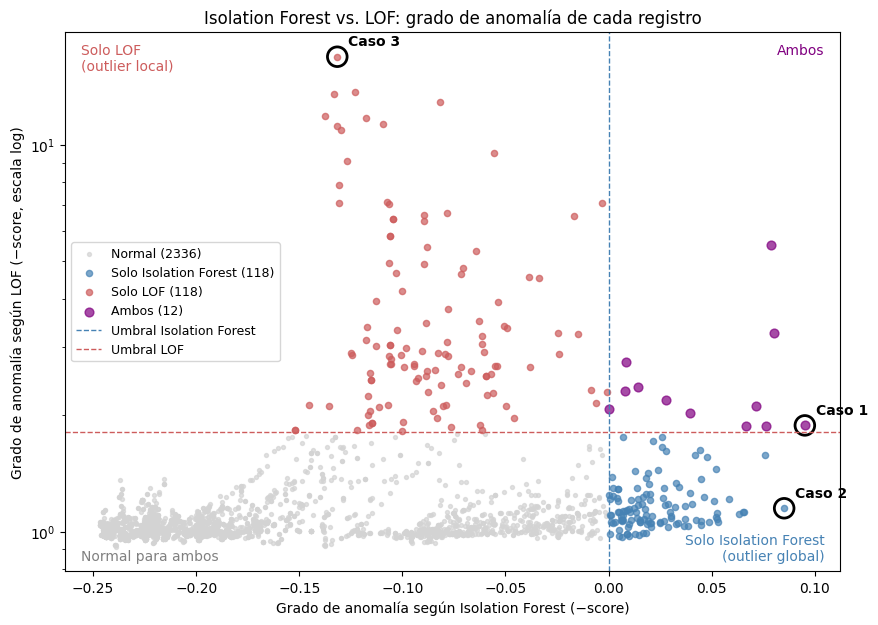

In [25]:
from scipy.stats import spearmanr

categoria = np.select(
    [(df_dedup.isof_pred == -1) & (df_dedup.lof_pred == -1),
     df_dedup.isof_pred == -1,
     df_dedup.lof_pred == -1],
    ["Ambos", "Solo Isolation Forest", "Solo LOF"],
    default="Normal",
)

# Invertimos el signo de los scores para leerlos como "grado de anomalía": más alto = más anómalo
anomalia_isof = -df_dedup["isof_score"]
anomalia_lof = -df_dedup["lof_score"]
umbral_isof = 0
umbral_lof = -lof.offset_

correlacion = spearmanr(anomalia_isof, anomalia_lof).statistic
print(f"Correlación de Spearman entre los scores de ambos métodos: {correlacion:.2f}")

fig, ax = plt.subplots(figsize=(10, 7))
for nombre, color, tamaño in [("Normal", "lightgray", 8), ("Solo Isolation Forest", "steelblue", 20),
                              ("Solo LOF", "indianred", 20), ("Ambos", "purple", 40)]:
    m = categoria == nombre
    ax.scatter(anomalia_isof[m], anomalia_lof[m], c=color, s=tamaño, alpha=0.7, label=f"{nombre} ({m.sum()})")

# Umbrales de cada método (surgen de contamination=0.05)
ax.axvline(umbral_isof, color="steelblue", linestyle="--", linewidth=1, label="Umbral Isolation Forest")
ax.axhline(umbral_lof, color="indianred", linestyle="--", linewidth=1, label="Umbral LOF")

# Nombre de cada zona
ax.text(0.02, 0.02, "Normal para ambos", transform=ax.transAxes, color="gray", fontsize=10)
ax.text(0.98, 0.02, "Solo Isolation Forest\n(outlier global)", transform=ax.transAxes, color="steelblue", ha="right", fontsize=10)
ax.text(0.02, 0.98, "Solo LOF\n(outlier local)", transform=ax.transAxes, color="indianred", va="top", fontsize=10)
ax.text(0.98, 0.98, "Ambos", transform=ax.transAxes, color="purple", ha="right", va="top", fontsize=10)

# Los 3 casos analizados
for caso, etiqueta in [(caso_1, "Caso 1"), (caso_2, "Caso 2"), (caso_3, "Caso 3")]:
    x, y = -caso["isof_score"], -caso["lof_score"]
    ax.scatter(x, y, s=200, facecolors="none", edgecolors="black", linewidths=2)
    ax.annotate(etiqueta, (x, y), xytext=(8, 8), textcoords="offset points", fontweight="bold")

ax.set_yscale("log")
ax.set_xlabel("Grado de anomalía según Isolation Forest (−score)")
ax.set_ylabel("Grado de anomalía según LOF (−score, escala log)")
ax.set_title("Isolation Forest vs. LOF: grado de anomalía de cada registro")
ax.legend(loc="center left", fontsize=9)
plt.show()

Cada punto es un registro, ubicado según el grado de anomalía que le asigna cada método (invertimos el signo de los scores para que un valor más alto signifique "más anómalo"). Las líneas punteadas son los umbrales de cada método, definidos por `contamination=0.05`, y dividen el gráfico en las mismas cuatro zonas del diagrama de Venn. El eje vertical está en escala logarítmica porque unos pocos registros tienen scores de LOF muy altos (el caso 3 llega a casi 17, mientras la mayoría ronda 1) y en escala lineal aplastarían al resto.

El gráfico resume lo que vimos en los tres casos:
- **Caso 1** (arriba a la derecha): lo marcan los dos métodos. Es el más anómalo para Isolation Forest, pero para LOF queda apenas por encima del umbral.
- **Caso 2** (abajo a la derecha): el segundo más anómalo para Isolation Forest, pero normal para LOF. Es un outlier global, no local.
- **Caso 3** (arriba a la izquierda): el más anómalo de todo el dataset para LOF, pero claramente normal para Isolation Forest. Es un outlier local, no global.

La correlación de Spearman entre los dos scores es 0.34: hay una relación positiva pero débil. Los métodos no se contradicen, pero ordenan los registros de forma muy distinta.

### 6.5 Síntesis: Isolation Forest vs. LOF

| | Isolation Forest | LOF |
|---|---|---|
| **Idea** | Un registro raro se aísla del resto con pocos cortes al azar | Un registro raro está en una zona más vacía que la de sus vecinos |
| **Mirada** | Global: compara cada registro contra todo el dataset | Local: compara cada registro contra su propio vecindario |
| **Detecta bien** | Registros en los bordes del rango de los datos, ya sea en una variable o en varias a la vez | Registros aislados de su vecindario, aunque sus valores sean comunes |
| **No detecta** | Registros raros cuyos valores están en el centro del rango de cada variable | Registros raros que forman un grupo con otros parecidos |
| **Parámetro clave** | `contamination` (proporción esperada de anomalías) | `n_neighbors` (tamaño del vecindario) y `contamination` |
| **Duplicados** | No le generan problemas | Los duplicados quedan a distancia 0 y distorsionan la densidad  |

En nuestro caso, los dos métodos marcaron 130 registros cada uno y coincidieron solo en 12. No es que uno funcione mejor que el otro, responden preguntas distintas. Por eso, en la práctica, conviene usarlos de forma complementaria. Los registros que marcan ambos (como el caso 1) son los candidatos más sólidos a revisar, y los que marca uno solo aportan información distinta según el método: un outlier global con Isolation Forest o un outlier local con LOF.